In [1]:
from sklearn.neighbors  import KNeighborsRegressor ,KNeighborsClassifier
from sklearn.linear_model import LinearRegression ,LogisticRegression
from sklearn.model_selection import (train_test_split ,
                                    cross_val_score ,
                                    StratifiedKFold,
                                    learning_curve ,
                                    GridSearchCV)
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.preprocessing import StandardScaler ,FunctionTransformer
from sklearn.pipeline import Pipeline ,make_pipeline
from sklearn.compose import ColumnTransformer ,TransformedTargetRegressor
from sklearn.decomposition import PCA
from sklearn.datasets import fetch_california_housing
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

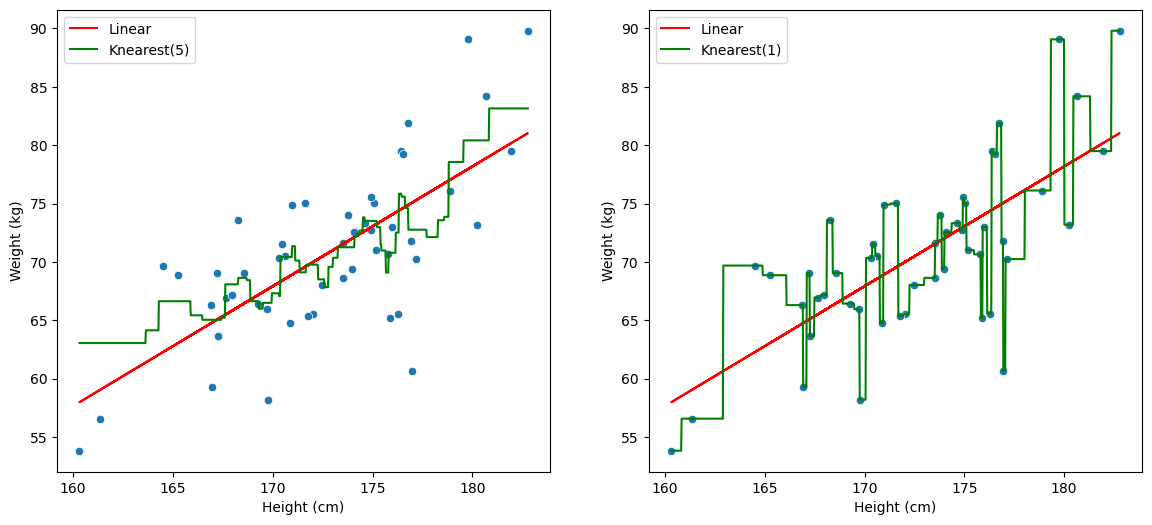

In [2]:
model_1 = KNeighborsRegressor( n_neighbors=1, 
                             p = 2 ,
                             weights= 'uniform' )
model_2 = LinearRegression()

data= np.random.multivariate_normal( [ 173, 70 ] ,
                                     [ [ 25, 20 ],
                                       [20, 36 ] ],
                                     size = (50,) 
                                   )
X,y = data[:,0].reshape(-1,1) , data[:,1].reshape(-1,1)
model_2.fit(X,y)
model_1.fit(X,y)
y_pred_2=model_2.predict(X)

X_line = np.linspace(X.min(), X.max(), 1000).reshape(-1, 1)
y_pred_1 = model_1.predict(X_line)


fig , ax = plt.subplots(1,2, figsize =(14,6))
sns.scatterplot (  x= data[:,0] , y= data[:,1] , ax = ax[1])
ax[1].plot( X, y_pred_2, color ='red' , label ='Linear' )
ax[1].plot( X_line, y_pred_1, color ='green' , label ='Knearest(1)' ) 
ax[1].legend()
ax[1].set_xlabel('Height (cm)')
ax[1].set_ylabel('Weight (kg)')



model_1 = KNeighborsRegressor( n_neighbors=5, 
                             p = 2 ,
                             weights= 'uniform' )
model_1.fit(X,y)
y_pred_1 = model_1.predict(X_line)

sns.scatterplot (  x= data[:,0] , y= data[:,1] , ax = ax[0])
ax[0].plot( X, y_pred_2, color ='red' , label ='Linear' )
ax[0].plot( X_line, y_pred_1, color ='green' , label ='Knearest(5)' ) 
ax[0].legend()
ax[0].set_xlabel('Height (cm)')
ax[0].set_ylabel('Weight (kg)')


plt.show()

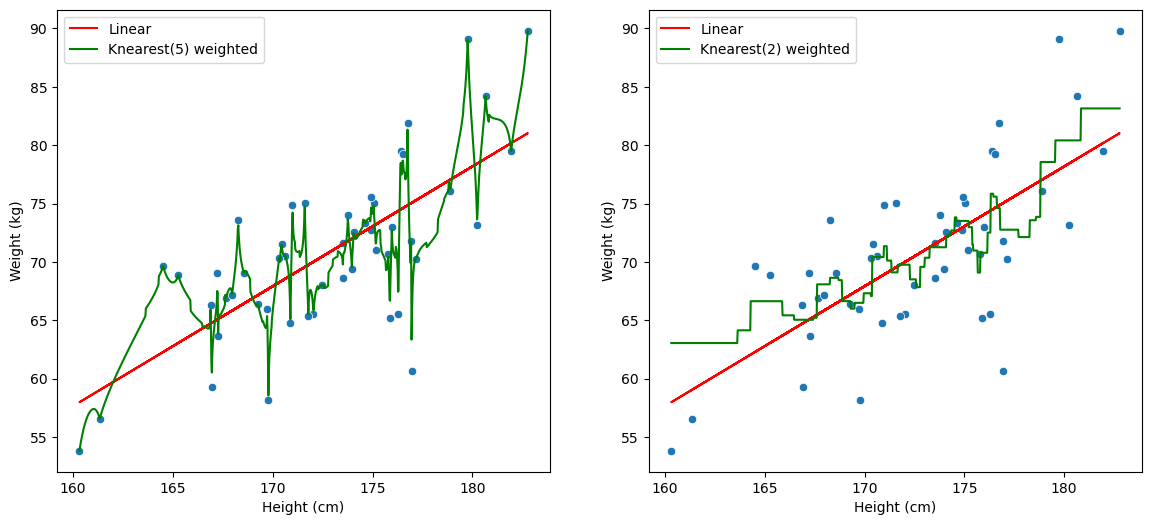

In [3]:
model_1 = KNeighborsRegressor( n_neighbors=2, 
                             p = 2 ,
                             weights= 'distance' )

fig , ax = plt.subplots(1,2, figsize =(14,6))
sns.scatterplot (  x= data[:,0] , y= data[:,1] , ax = ax[1])
ax[1].plot( X, y_pred_2, color ='red' , label ='Linear' )
ax[1].plot( X_line, y_pred_1, color ='green' , label ='Knearest(2) weighted' ) 
ax[1].legend()
ax[1].set_xlabel('Height (cm)')
ax[1].set_ylabel('Weight (kg)')



model_1 = KNeighborsRegressor( n_neighbors=5, 
                             p = 2 ,
                             weights= 'distance' )
model_1.fit(X,y)
y_pred_1 = model_1.predict(X_line)

sns.scatterplot (  x= data[:,0] , y= data[:,1] , ax = ax[0])
ax[0].plot( X, y_pred_2, color ='red' , label ='Linear' )
ax[0].plot( X_line, y_pred_1, color ='green' , label ='Knearest(5) weighted' ) 
ax[0].legend()
ax[0].set_xlabel('Height (cm)')
ax[0].set_ylabel('Weight (kg)')


plt.show()

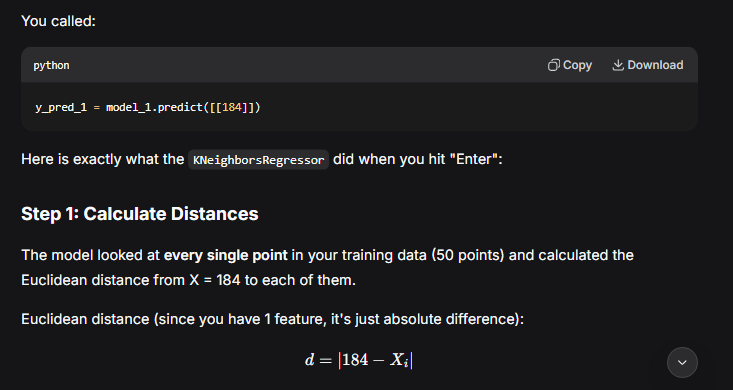

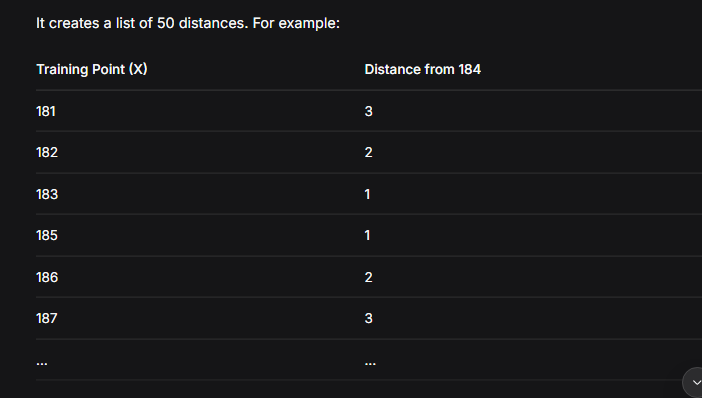

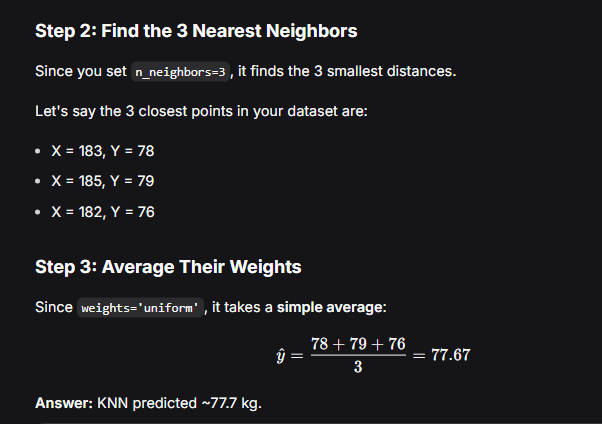

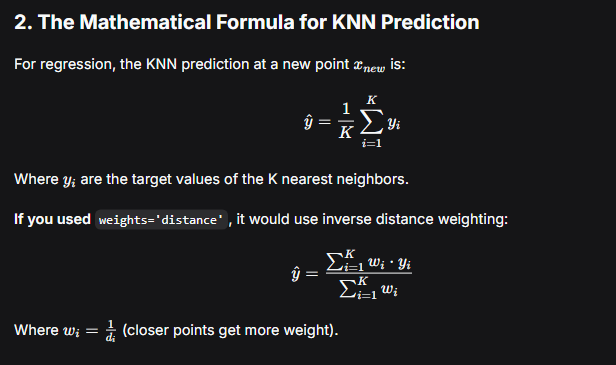

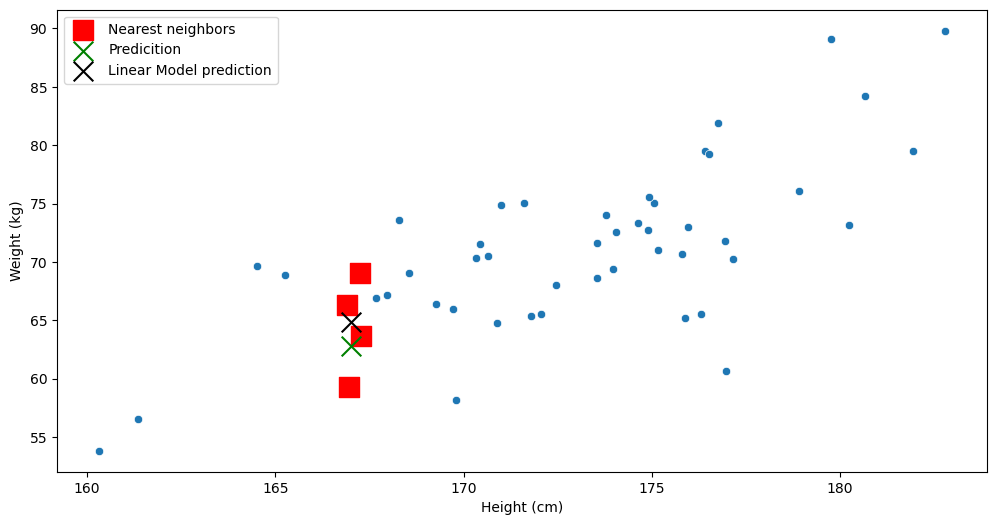

In [4]:
model_1 = KNeighborsRegressor( n_neighbors=4, 
                             p = 2 ,
                             weights= 'distance' )
model_1.fit(X,y)
distances, indices = model_1.kneighbors([[167]])

plt.figure( figsize = (12,6))
sns.scatterplot (  x= data[:,0] , y= data[:,1] )
plt.scatter( X[indices][0] , y[indices][0], color = 'red' , label ='Nearest neighbors' , s = 200, marker = 's' )
plt.scatter ( [167] , model_1.predict([[167]]) , color = 'green' , label = 'Predicition' , s= 200, marker = 'x')
plt.scatter ( [167] , model_2.predict([[167]]) , color = 'black' , label = 'Linear Model prediction' , s= 200, marker = 'x')
plt.legend()
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.show()

In [5]:
model_2.coef_  , model_2.intercept_#A unit increase in height adds 0.8kg

(array([[1.02652244]]), array([-106.59474654]))

In [6]:
scale = StandardScaler()
X_t = scale.fit_transform(X)
model_2.fit(X_t, y ) 
model_2.coef_ , model_2.intercept_

(array([[5.11046653]]), array([70.67799808]))

This is scaled coeffecients whichs means 1 standard deviation of height adds 5.12 kg

and the intercept means the when height = height mean the intercept term not when hieght = 0 which means 71kg is weight when mean hieght

In [7]:
model_2.coef_ /scale.scale_[0]  #same scaling as above

array([[1.02652244]])

In [8]:

model_2.intercept_[0] - (model_2.coef_[0][0] * scale.mean_[0] / scale.scale_[0])


np.float64(-106.59474654365097)

The same thing applies for the logistic regression coeffecients in the previous notebooks

In [9]:
model_1 = KNeighborsRegressor( n_neighbors=5, 
                             p = 2 ,
                             weights= 'uniform' )
model_2 = LinearRegression()

data= np.random.multivariate_normal( [ 173, 70 ] ,
                                     [ [ 25, 20 ],
                                       [20, 36 ] ],
                                     size = (50,) 
                                   )
X,y = data[:,0].reshape(-1,1) , data[:,1].reshape(-1,1)
model_2.fit(X,y)
model_1.fit(X,y)

r2_score(y , model_1.predict(X)) , r2_score(y, model_2.predict(X)) 

(0.5037810252327555, 0.4349373622879318)

If the data is non-linear knn works well good (low dimension) , if the data is linear linear regression is better

Linear regression with non linear data with high dimension can work better with polynomial features and the regularization

In [10]:
root_mean_squared_error(y , model_1.predict(X)) , root_mean_squared_error(y, model_2.predict(X)) 

(3.692752946726962, 3.9405955813922087)

In [11]:
df = fetch_california_housing(as_frame=True).frame
df.head(4)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413


In [12]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


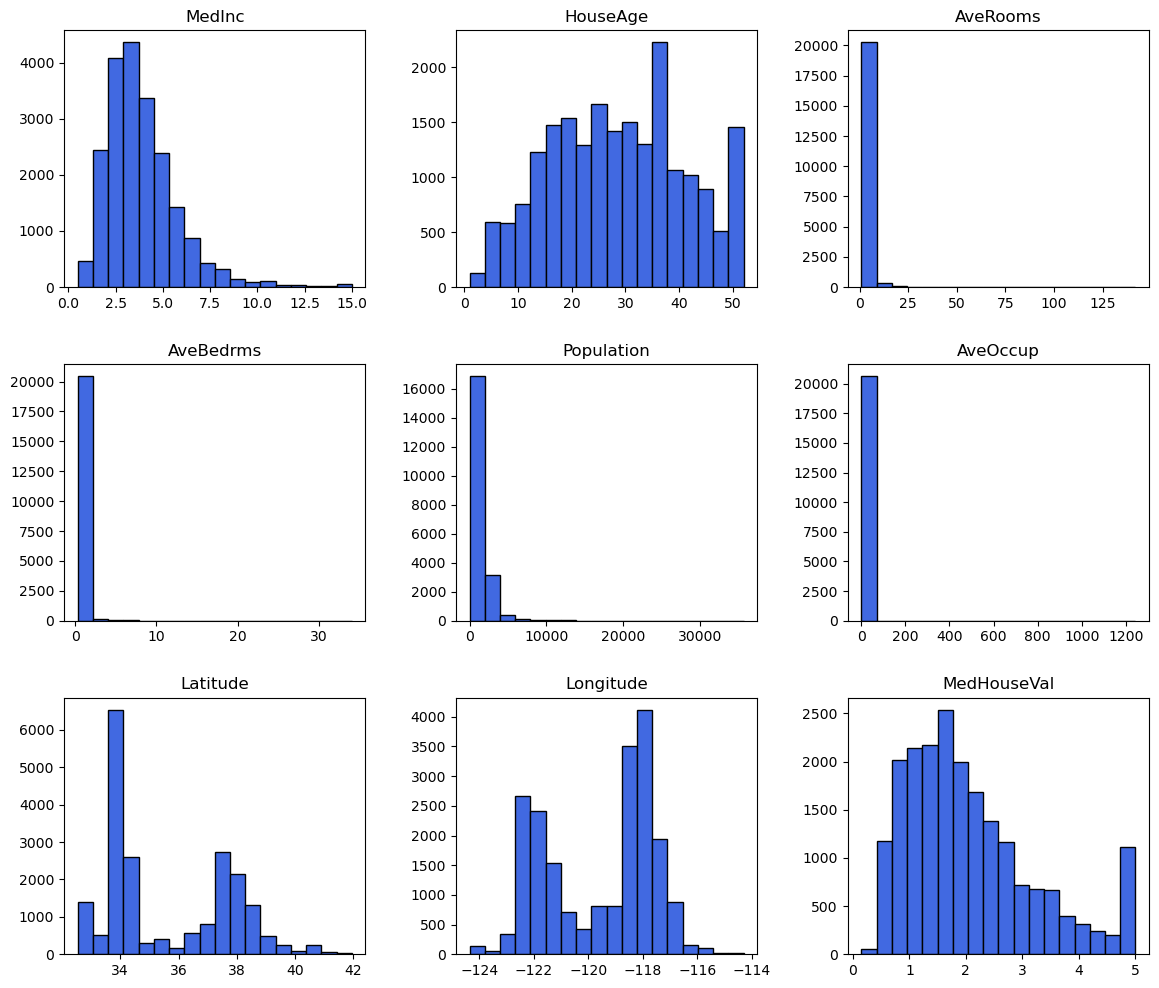

In [13]:
df.hist(grid = False, figsize = (14,12) , color = 'royalblue' ,edgecolor ='black', bins = 18 )
plt.show()

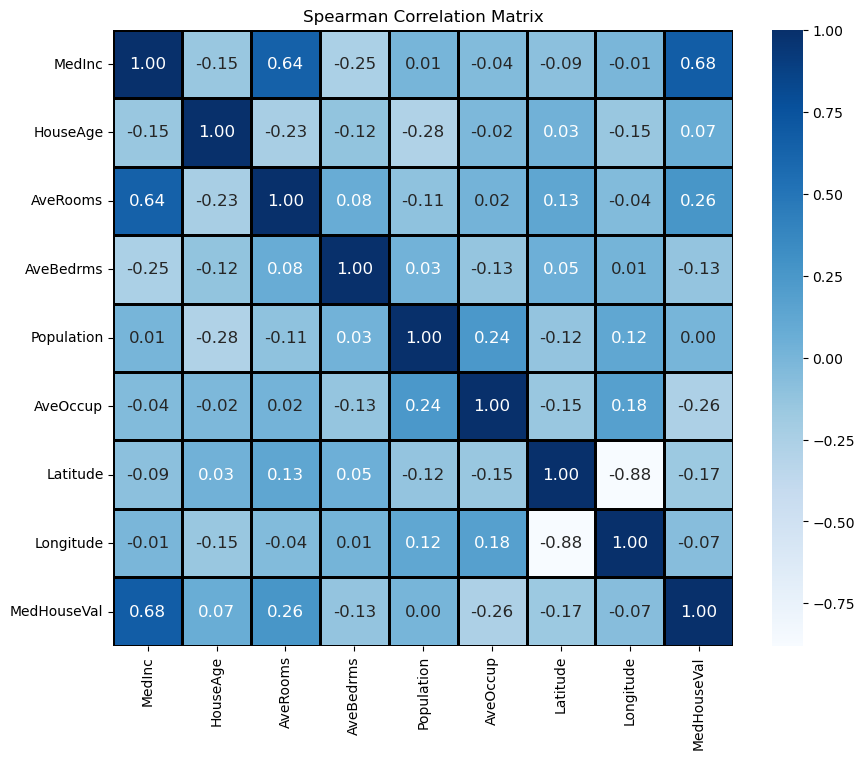

In [14]:
corr = df.corr(method= 'spearman') 
plt.figure(figsize = (10,8))
plt.title('Spearman Correlation Matrix')
sns.heatmap( corr, annot = True, annot_kws = {'size':12} , linecolor='black' , linewidths=1 , cmap ='Blues',fmt = '.2f')
plt.show()

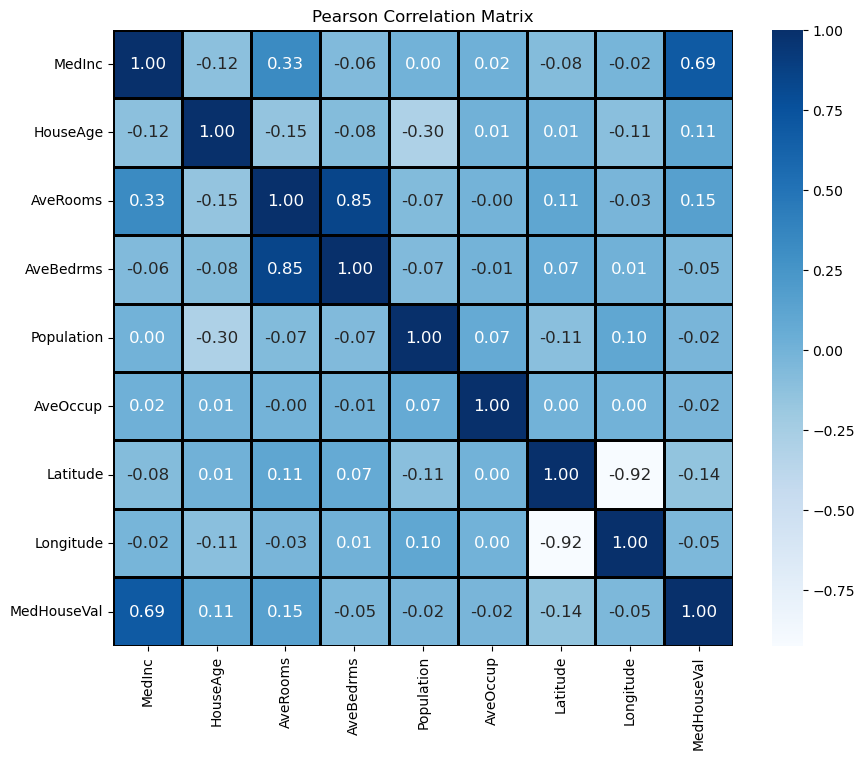

In [15]:
corr = df.corr() 
plt.figure(figsize = (10,8))
plt.title('Pearson Correlation Matrix')
sns.heatmap( corr, annot = True, annot_kws = {'size':12} , linecolor='black' , linewidths=1 , cmap ='Blues',fmt = '.2f')
plt.show()

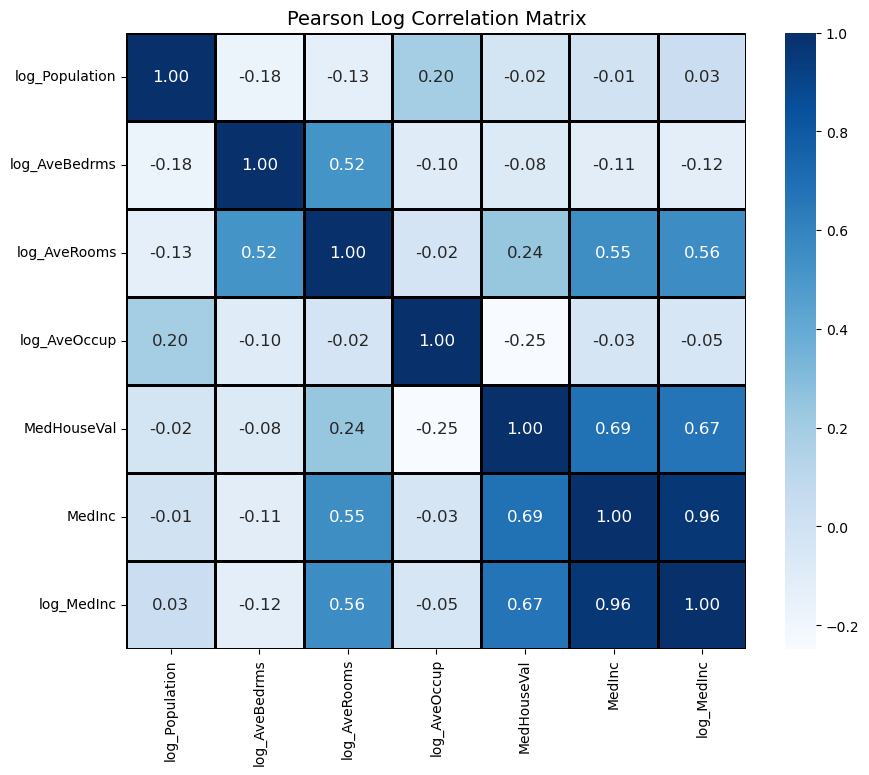

In [16]:
df['log_Population'] = np.log1p( df['Population'] ) 
df['log_AveBedrms'] = np.log1p( df['AveBedrms'] ) 
df['log_AveRooms'] = np.log1p( df['AveRooms'] ) 
df['log_AveOccup'] = np.log1p( df['AveOccup'] ) 
df['log_AveOccup'] = np.log1p( df['AveOccup'] ) 
df['log_MedInc'] = np.log1p( df['MedInc'] ) 
columns = ['log_Population', 'log_AveBedrms' ,'log_AveRooms' ,'log_AveOccup' ,'MedHouseVal' ,'MedInc' ,'log_MedInc']

corr =df[columns].corr() 
plt.figure(figsize = (10,8))
plt.title('Pearson Log Correlation Matrix',fontsize =14)
sns.heatmap( corr, annot = True, annot_kws = {'size':12} , linecolor='black' , linewidths=1 , cmap ='Blues',fmt = '.2f')
plt.show()

The correlation after log transformation did chagned because it changed from exponential to straight line(right skewed to normal distribution)

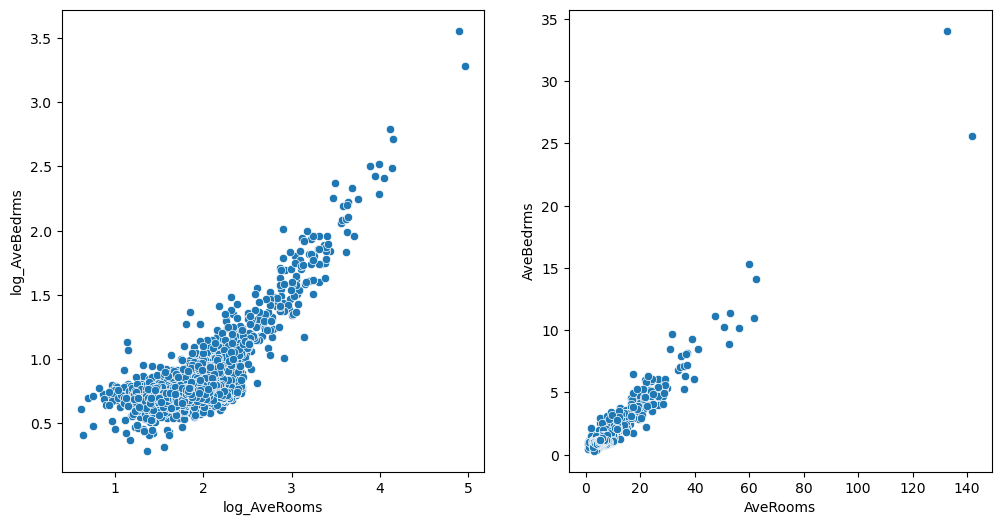

In [17]:
fig,ax = plt.subplots( 1,2, figsize = (12,6))
sns.scatterplot( data = df, x='log_AveRooms' , y = 'log_AveBedrms' , ax=ax[0])
sns.scatterplot( data = df, x='AveRooms' , y = 'AveBedrms' , ax=ax[1])
plt.show()

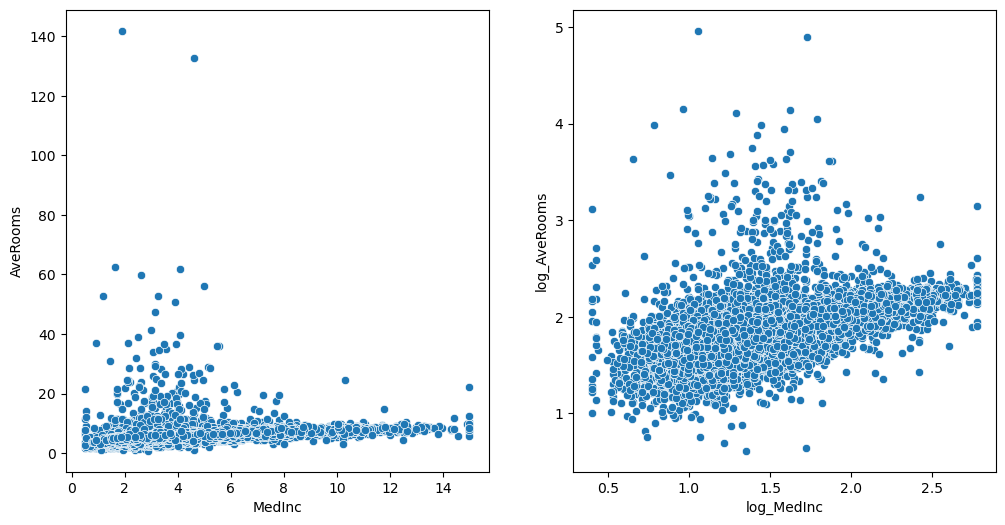

In [18]:
fig,ax = plt.subplots( 1,2, figsize = (12,6))
sns.scatterplot( data = df, x='MedInc' , y = 'AveRooms' , ax=ax[0])
sns.scatterplot( data = df, x='log_MedInc' , y = 'log_AveRooms' , ax=ax[1])
plt.show()

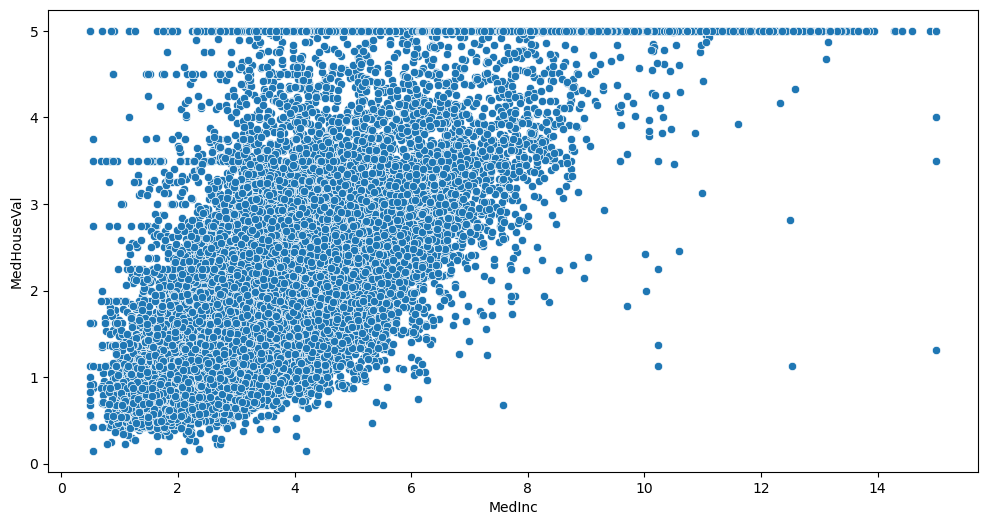

In [19]:
fig,ax = plt.subplots(figsize = (12,6))
sns.scatterplot( data = df, x='MedInc' , y = 'MedHouseVal' )
plt.show()

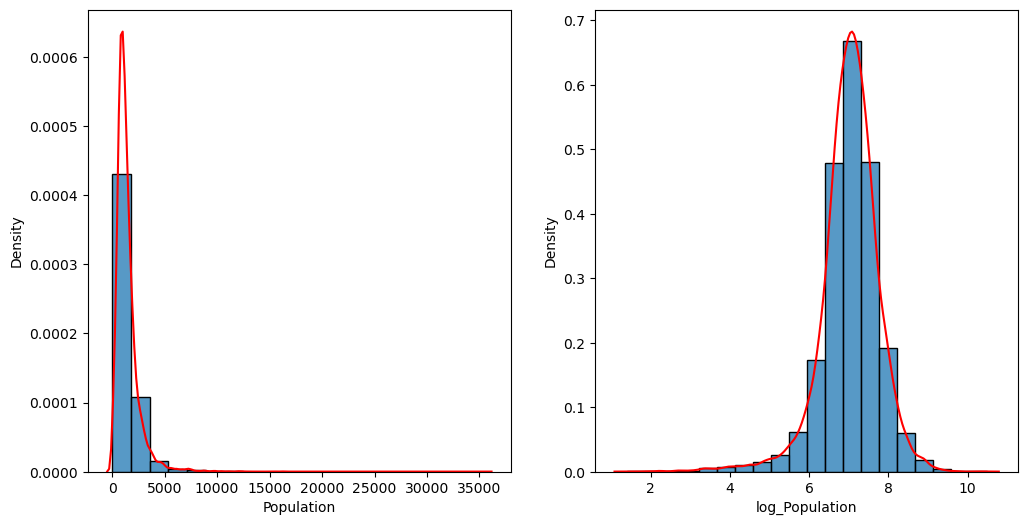

In [20]:
fig,ax = plt.subplots( 1,2, figsize = (12,6))
sns.histplot ( data = df, x='Population' , 
               bins = 20 , ax = ax[0], stat = 'density') 
sns.kdeplot ( data = df, x='Population' ,
              color = 'red' , ax = ax[0]) 
sns.histplot ( data = df, x='log_Population' ,
               bins = 20 , ax = ax[1], stat = 'density') 
sns.kdeplot ( data = df, x='log_Population' , 
              color = 'red' , ax = ax[1]) 
plt.show()

In [21]:
columns_1 = ['MedInc', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']
columns_2 = ['HouseAge', 'Latitude', 'Longitude']
y = df['MedHouseVal']
X = df[columns_1 + columns_2]

pipeline_1 = make_pipeline( FunctionTransformer(func=np.log1p, feature_names_out='one-to-one', validate=True),
                            StandardScaler() )

preprocess = ColumnTransformer( transformers=[ ('log_z_scaling', pipeline_1, columns_1),
                                               ('z_scaling', StandardScaler(), columns_2)],
                                                remainder='drop')

pipeline = Pipeline([ ('preprocess', preprocess), 
                      ('model', KNeighborsRegressor(n_neighbors=10, p=2, weights='uniform'))  
                    ])
X_train, X_test, y_train, y_test = train_test_split( X,y,
                                                     random_state=26, 
                                                     test_size =0.2 ) 

train_sizes, train_scores, test_scores = learning_curve(pipeline, X_train,
                                                        y_train, 
                                                        cv = 5, 
                                                        train_sizes= np.linspace(0.1, 1, 10 ) ,
                                                        shuffle= True, 
                                                        random_state=26,
                                                        scoring= 'neg_root_mean_squared_error' 
                                                       )




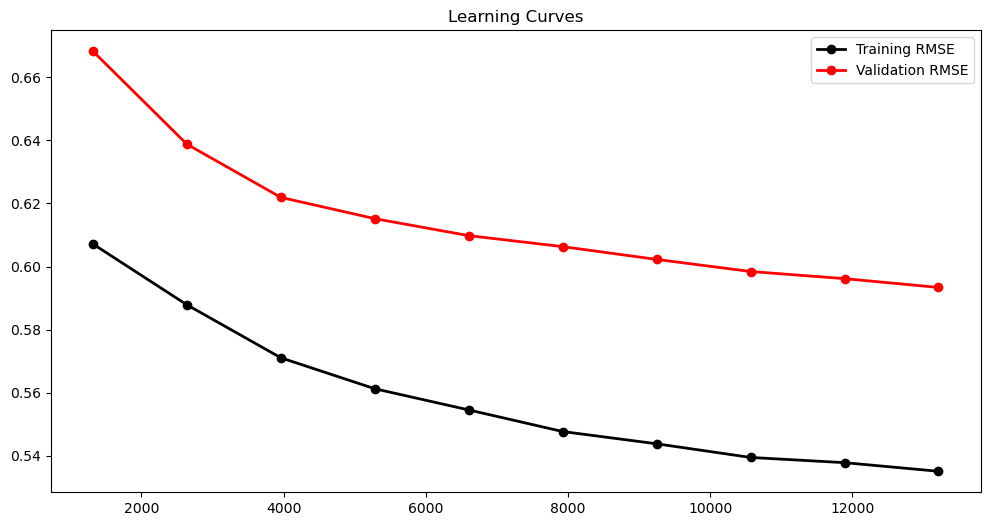

In [22]:
plt.figure(figsize = (12,6)) 
plt.plot( train_sizes ,-train_scores.mean(axis = 1), color = 'black' , marker= 'o' , linewidth =2 , label='Training RMSE')
plt.plot( train_sizes ,-test_scores.mean(axis = 1), color = 'red' , marker= 'o' , linewidth =2 , label='Validation RMSE')
plt.legend()
plt.title('Learning Curves')
plt.show()

Here the model is overfitting the rmse might look small but the medianhouse value is in hunderd of thousands of dollars

which means the prediction is off by 60,000 dollars

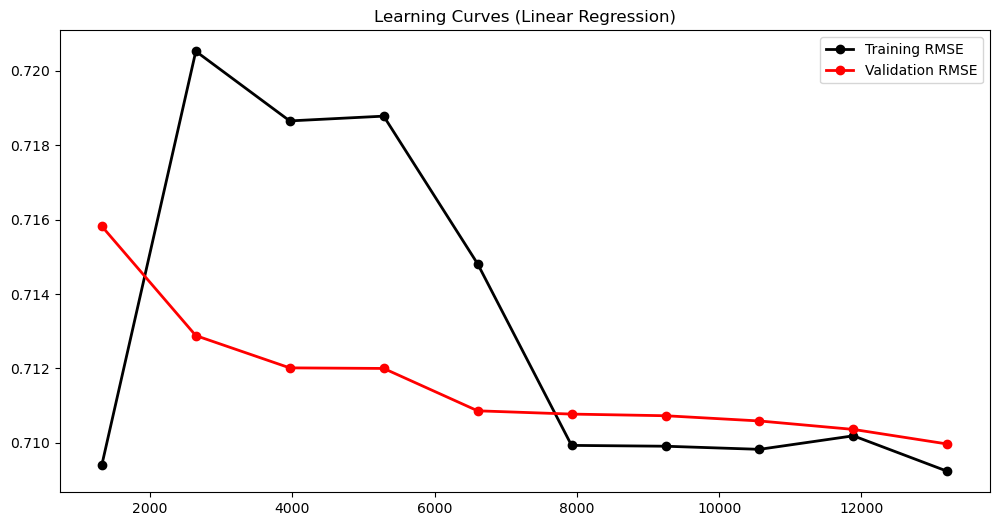

In [23]:
pipeline = Pipeline([ ('preprocess', preprocess), 
                      ('model', LinearRegression())  
                    ])
X_train, X_test, y_train, y_test = train_test_split( X,y,
                                                     random_state=26, 
                                                     test_size =0.2 ) 

train_sizes, train_scores, test_scores = learning_curve(pipeline, X_train,
                                                        y_train, 
                                                        cv = 5, 
                                                        train_sizes= np.linspace(0.1, 1, 10 ) ,
                                                        shuffle= True, 
                                                        random_state=26,
                                                        scoring= 'neg_root_mean_squared_error' 
                                                       )

plt.figure(figsize = (12,6)) 
plt.plot( train_sizes ,-train_scores.mean(axis = 1), color = 'black' , marker= 'o' , linewidth =2 , label='Training RMSE')
plt.plot( train_sizes ,-test_scores.mean(axis = 1), color = 'red' , marker= 'o' , linewidth =2 , label='Validation RMSE')
plt.legend()
plt.title('Learning Curves (Linear Regression)')
plt.show()


Too simple underfitting model 

In [24]:
pipeline.fit(X_train, y_train)

model_coefs = pipeline.named_steps['model'].coef_
preprocess_step = pipeline.named_steps['preprocess']

scale_col1 = preprocess_step.named_transformers_['log_z_scaling'].named_steps['standardscaler'].scale_
scale_col2 = preprocess_step.named_transformers_['z_scaling'].scale_
all_scales = np.concatenate([scale_col1, scale_col2])

unscaled_coefs = model_coefs / all_scales

feature_names = columns_1 + columns_2
results = pd.DataFrame({
    'Feature': feature_names,
    'Unscaled_Coef ($100k)': unscaled_coefs,
    'Dollar_Impact': unscaled_coefs * 100_000
})

results

,Feature,Unscaled_Coef ($100k),Dollar_Impact
0,MedInc,2.264367,226436.650608
1,AveRooms,-0.730998,-73099.799814
2,AveBedrms,1.751813,175181.269099
3,Population,0.014325,1432.495990
4,AveOccup,-1.118868,-111886.836267
5,HouseAge,0.011518,1151.826031
6,Latitude,-0.408961,-40896.140173
7,Longitude,-0.407327,-40732.732864


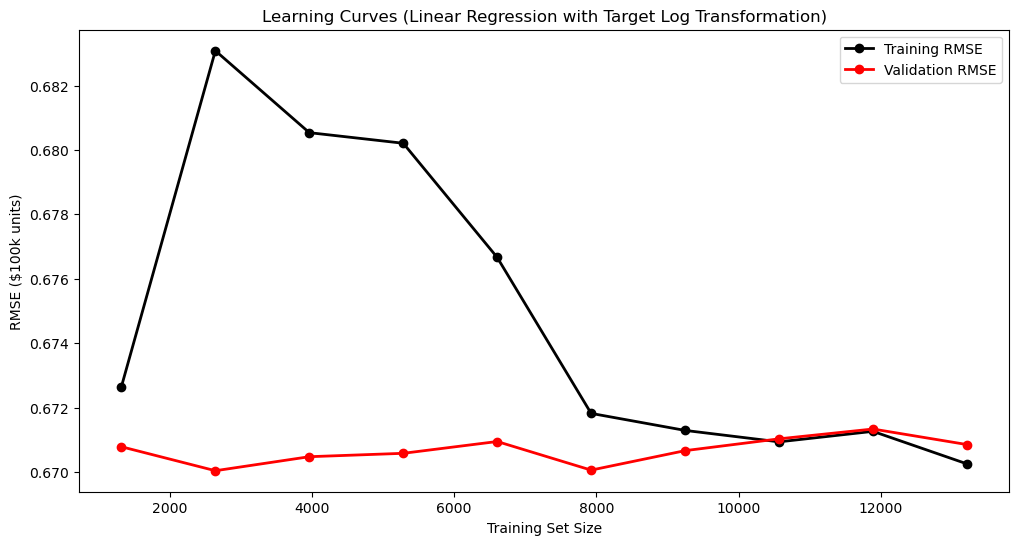

In [25]:
model_log_y = TransformedTargetRegressor(
    regressor=pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

train_sizes, train_scores, test_scores = learning_curve(
    model_log_y, 
    X_train, 
    y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1, 10),
    shuffle=True,
    random_state=26,
    scoring='neg_root_mean_squared_error'
)

plt.figure(figsize=(12, 6))
plt.plot(train_sizes, -train_scores.mean(axis=1), color='black', marker='o', linewidth=2, label='Training RMSE')
plt.plot(train_sizes, -test_scores.mean(axis=1), color='red', marker='o', linewidth=2, label='Validation RMSE')
plt.legend()
plt.title('Learning Curves (Linear Regression with Target Log Transformation)')
plt.ylabel('RMSE ($100k units)')
plt.xlabel('Training Set Size')
plt.show()

Let $y$ represent the raw target value in original dollar units, $\hat{y}$ represent the predicted house price in raw dollar units, and $\hat{z}$ represent the model's prediction on the log scale.

When training a linear regression model without transforming the target, Ordinary Least Squares (OLS) minimizes the squared absolute difference between actual and predicted target values:

$$L_{\text{raw}} = (y - \hat{y})^2$$

When applying a logarithmic transformation $z = \ln(y)$, the model learns parameters to predict $\hat{z}$. The loss function minimized during training is:

$$L_{\text{log}} = (z - \hat{z})^2 = (\ln(y) - \hat{z})^2$$

Since the predicted value in dollar terms is $\hat{y} = e^{\hat{z}}$ (meaning $\hat{z} = \ln(\hat{y})$), substituting this back into the loss equation gives:

$$L_{\text{log}} = (\ln(y) - \ln(\hat{y}))^2 = \left( \ln\left(\frac{y}{\hat{y}}\right) \right)^2$$

Using the logarithmic approximation $\ln(1 + x) \approx x$ for small relative differences:

$$\ln\left(\frac{y}{\hat{y}}\right) = \ln\left(1 + \frac{y - \hat{y}}{\hat{y}}\right) \approx \frac{y - \hat{y}}{\hat{y}}$$

Squaring this term reveals the effective loss function optimized during training:

$$L_{\text{log}} \approx \left( \frac{y - \hat{y}}{\hat{y}} \right)^2$$

**Key Differences Between the Two Loss Functions**

* **Without Log Transformation ($L_{\text{raw}}$):** The model minimizes absolute dollar errors. An error of $\$50,000$ on a $\$100,000$ home adds $(50,000)^2 = 2,500,000,000$ to total loss. An error of $\$50,000$ on a $\$1,000,000$ home adds the exact same $2,500,000,000$.
* **With Log Transformation ($L_{\text{log}}$):** The model minimizes relative percentage errors. A $50\%$ error on a $\$100,000$ home adds approximately $(0.50)^2 = 0.25$ to total loss, whereas a $5\%$ error ($\$50,000$) on a $\$1,000,000$ home adds only $(0.05)^2 = 0.0025$.

Your formula $(y - e^y)^2$ is incorrect. The model does not subtract $e^y$ from $y$; it minimizes $(\ln(y) - \ln(\hat{y}))^2$, measuring relative percentage deviations rather than raw dollar differences.

In [26]:
model_log_y = TransformedTargetRegressor(
    regressor=pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)
model_log_y.fit(X_train, y_train)

fitted_pipeline = model_log_y.regressor_
raw_coefs = fitted_pipeline.named_steps['model'].coef_
preprocess_step = fitted_pipeline.named_steps['preprocess']

scale_col1 = preprocess_step.named_transformers_['log_z_scaling'].named_steps['standardscaler'].scale_
scale_col2 = preprocess_step.named_transformers_['z_scaling'].scale_
all_scales = np.concatenate([scale_col1, scale_col2])

unscaled_coefs = raw_coefs / all_scales

feature_names = columns_1 + columns_2
interpretations = []

for feat, beta in zip(feature_names, unscaled_coefs):
    if feat in columns_1:
        interpretations.append(f"{beta:+.4f}% price change per 1% increase in (1 + X)")
    else:
        pct_change = (np.exp(beta) - 1) * 100
        interpretations.append(f"{pct_change:+.4f}% price change per 1-unit increase in X")

results = pd.DataFrame({
    'Feature': feature_names,
    'Unscaled Coef': unscaled_coefs,
    'Percentage Impact on House Value': interpretations
})

results

,Feature,Unscaled Coef,Percentage Impact on House Value
0,MedInc,0.710589,+0.7106% price change per 1% increase in (1 + X)
1,AveRooms,-0.261743,-0.2617% price change per 1% increase in (1 + X)
2,AveBedrms,0.588185,+0.5882% price change per 1% increase in (1 + X)
3,Population,0.011141,+0.0111% price change per 1% increase in (1 + X)
4,AveOccup,-0.336113,-0.3361% price change per 1% increase in (1 + X)
5,HouseAge,0.002769,+0.2773% price change per 1-unit increase in X
6,Latitude,-0.149298,-13.8687% price change per 1-unit increase in X
7,Longitude,-0.147368,-13.7024% price change per 1-unit increase in X


In [27]:
pipeline = Pipeline([ ('preprocess', preprocess), 
                      ('model', KNeighborsRegressor( p=2, weights='uniform'))  
                    ])
param_grid = { 'model__n_neighbors' : [ 5,8,10,15,20,25] }
grid_search = GridSearchCV( pipeline, 
                            param_grid = param_grid,
                            scoring= 'neg_root_mean_squared_error',
                            cv= 5, 
                          ) 
grid_search.fit(X_train,y_train)

,estimator,Pipeline(step...Regressor())])
,param_grid,"{'model__n_neighbors': [5, 8, ...]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('log_z_scaling', ...), ('z_scaling', ...)]"


In [28]:
-grid_search.best_score_ , grid_search.best_params_

(np.float64(0.5923726446491366), {'model__n_neighbors': 20})

In [29]:
my_model= grid_search.best_estimator_
r2_score(y_train, my_model.predict(X_train)) , r2_score(y_test, my_model.predict(X_test)) 

(0.7682899121868978, 0.7510915683862348)

In [30]:
root_mean_squared_error(y_train, my_model.predict(X_train)) , root_mean_squared_error(y_test, my_model.predict(X_test)) 

(0.5571946279561871, 0.5684456062364823)

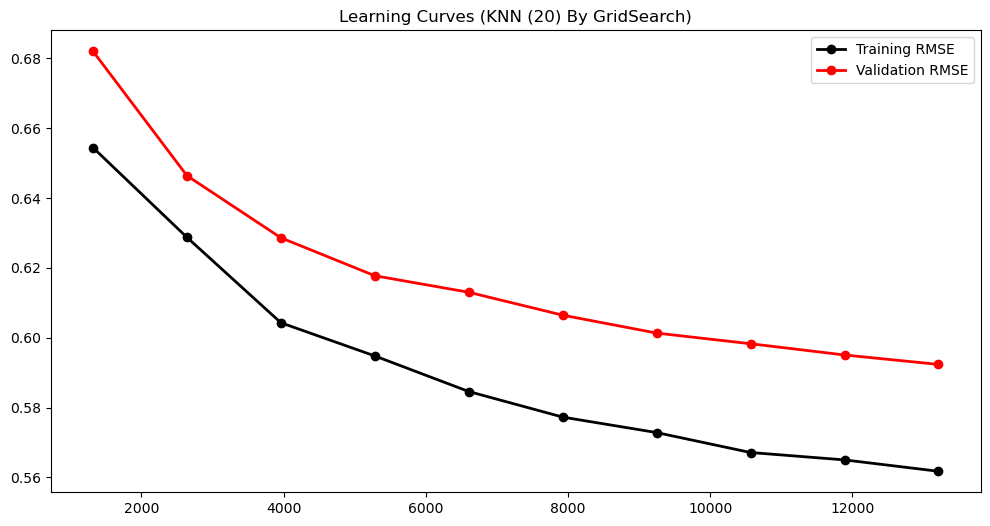

In [31]:
train_sizes, train_scores, test_scores = learning_curve(my_model, X_train,
                                                        y_train, 
                                                        cv = 5, 
                                                        train_sizes= np.linspace(0.1, 1, 10 ) ,
                                                        shuffle= True, 
                                                        random_state=26,
                                                        scoring= 'neg_root_mean_squared_error' 
                                                       )

plt.figure(figsize = (12,6)) 
plt.plot( train_sizes ,-train_scores.mean(axis = 1), color = 'black' , marker= 'o' , linewidth =2 , label='Training RMSE')
plt.plot( train_sizes ,-test_scores.mean(axis = 1), color = 'red' , marker= 'o' , linewidth =2 , label='Validation RMSE')
plt.legend()
plt.title('Learning Curves (KNN (20) By GridSearch)')
plt.show()


In [32]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal', 'log_Population',
       'log_AveBedrms', 'log_AveRooms', 'log_AveOccup', 'log_MedInc'],
      dtype='object')

In [34]:
df.drop(columns=['log_Population', 'log_AveBedrms', 'log_AveRooms', 'log_AveOccup', 'log_MedInc', 'log_Population'], inplace=True)


In [35]:
df['Model Prediction'] = my_model.predict(X) 

df.sample(8)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,Model Prediction
6054,5.6513,26.0,7.193634,1.066313,1389.0,3.684350,34.00,-117.85,2.279,2.50305
8961,4.6932,40.0,4.492424,1.037879,371.0,2.810606,34.02,-118.40,3.328,2.45625
9913,2.6346,44.0,5.013587,1.099185,1922.0,2.611413,38.30,-122.30,1.398,1.45795
16353,4.5000,30.0,5.533333,0.977778,167.0,3.711111,38.04,-121.32,0.928,1.56825
4311,1.8790,28.0,2.847969,1.073394,2548.0,3.339450,34.09,-118.32,2.188,2.20340
13466,2.4053,17.0,5.477022,1.110294,4115.0,3.782169,34.12,-117.38,1.052,1.34710
988,6.6827,13.0,6.916607,0.966211,4389.0,3.155284,37.70,-121.86,3.137,3.24350
9265,4.6650,14.0,7.492188,1.109375,2047.0,3.198437,36.92,-119.81,1.213,1.44555
